In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PULSE_FOLDER = "AVG_PULSE"
A_RESULTS_CSV_PATH = "A_results.csv"

AXES_ORDER = ["d1", "d2", "d3", "d4"]

# Plotting field of view.
# Change this if the real field of view is not 200 µm × 200 µm.
EXTENT_UM = [-100, 100, -100, 100]

# Assumption:
# Pulse files are stored in volts and use the same voltage scale
# as the ODMR slopes saved in A_results.csv.

In [19]:
#inspect poulse datab
# Expected array structure:
#   column 0      = time [s]
#   columns 1:end = pixel voltage traces [V]
# ============================================================

pulse_files = [
    os.path.join(PULSE_FOLDER, f"Pulse_avg_{axis}.npy")

    for axis in AXES_ORDER
]

for file in pulse_files:
    if not os.path.exists(file):
        raise FileNotFoundError(f"Missing pulse file: {file}")

pulse_arrays = [np.load(file) for file in pulse_files]

for axis, file, arr in zip(AXES_ORDER, pulse_files, pulse_arrays):
    print(axis, file)
    print("  shape:", arr.shape)
    print("  time range [s]:", arr[:, 0].min(), "to", arr[:, 0].max())
    print("  signal range [V assumed]:", arr[:, 1:].min(), "to", arr[:, 1:].max())
    print()

d1 AVG_PULSE/Pulse_avg_d1.npy
  shape: (457, 962)
  time range [s]: 0.0 to 0.1761984
  signal range [V assumed]: -0.006530097653609521 to 0.004275400259864077

d2 AVG_PULSE/Pulse_avg_d2.npy
  shape: (457, 962)
  time range [s]: 0.0 to 0.1761984
  signal range [V assumed]: -0.0017997104314252089 to 0.0007849333013160025

d3 AVG_PULSE/Pulse_avg_d3.npy
  shape: (457, 962)
  time range [s]: 0.0 to 0.1761984
  signal range [V assumed]: -0.0006792898297625359 to 0.0006051410445142222

d4 AVG_PULSE/Pulse_avg_d4.npy
  shape: (457, 962)
  time range [s]: 0.0 to 0.1761984
  signal range [V assumed]: -0.00029076577657876615 to 0.000337853112942851



In [20]:
# ============================================================
# Stack pulse data
# ============================================================

time_s = pulse_arrays[0][:, 0]

for axis, arr in zip(AXES_ORDER, pulse_arrays):
    if not np.allclose(arr[:, 0], time_s):
        raise ValueError(f"Time axis mismatch for {axis}")

# Shape:
#   voltage_stack[channel, time, pixel]
voltage_stack = np.stack([arr[:, 1:] for arr in pulse_arrays], axis=0)

n_channels, n_timepoints, n_pixels = voltage_stack.shape

grid_size = int(np.sqrt(n_pixels))
if grid_size * grid_size != n_pixels:
    raise ValueError(f"Number of pixels is not square: {n_pixels}")

dt_s = np.median(np.diff(time_s))
frame_rate_hz = 1.0 / dt_s

print("voltage_stack shape:", voltage_stack.shape)
print("channels:", n_channels)
print("timepoints:", n_timepoints)
print("pixels:", n_pixels)
print("grid:", grid_size, "x", grid_size)
print(f"dt = {dt_s:.9f} s")
print(f"frame rate = {frame_rate_hz:.3f} Hz")

voltage_stack shape: (4, 457, 961)
channels: 4
timepoints: 457
pixels: 961
grid: 31 x 31
dt = 0.000386400 s
frame rate = 2587.992 Hz


In [21]:
# ============================================================
# Pulse voltage diagnostics
# ============================================================

pulse_rows = []

for i, axis in enumerate(AXES_ORDER):
    values = voltage_stack[i].ravel()

    pulse_rows.append({
        "axis": axis,
        "min_V": np.nanmin(values),
        "max_V": np.nanmax(values),
        "mean_V": np.nanmean(values),
        "std_V": np.nanstd(values),
        "p01_V": np.nanpercentile(values, 1),
        "p50_V": np.nanpercentile(values, 50),
        "p99_V": np.nanpercentile(values, 99),
    })

pulse_scale_df = pd.DataFrame(pulse_rows)
display(pulse_scale_df)

print("Interpretation:")
print("- These values are assumed to be volts.")
print("- The absolute values may include offsets.")
print("- The important quantity for magnetometry is phase - OFF, i.e. ΔV.")
print("- Later we check whether ΔV / slope gives reasonable Δν in MHz.")

,axis,min_V,max_V,mean_V,std_V,p01_V,p50_V,p99_V
0,d1,-0.006530,0.004275,-1.107764e-05,0.000435,-0.001391,1.747162e-06,0.000975
1,d2,-0.001800,0.000785,-7.068421e-06,0.000149,-0.000919,1.082889e-06,0.000445
2,d3,-0.000679,0.000605,-4.649229e-08,0.000067,-0.000305,5.718141e-07,0.000276
3,d4,-0.000291,0.000338,1.887273e-06,0.000032,-0.000086,1.115191e-07,0.000106


Interpretation:
- These values are assumed to be volts.
- The absolute values may include offsets.
- The important quantity for magnetometry is phase - OFF, i.e. ΔV.
- Later we check whether ΔV / slope gives reasonable Δν in MHz.


Selected intervals:
OFF: 0.000000 to 0.050000 s | frames 0 to 129 | n = 130
NEG: 0.055300 to 0.058900 s | frames 144 to 152 | n = 9
POS: 0.060900 to 0.064500 s | frames 158 to 166 | n = 9



Selected frames for phase analysis:
OFF: frames 0 to 129 (mean)
     time 0.000000 to 0.049846 s
     mean signal = -1.91819e-06 V

POS: frame 166
     time 0.064142 s
     mean ΔV = 0.000316011 V
     percentile in POS interval: 88.9%

NEG: frame 152
     time 0.058733 s
     mean ΔV = -0.000521677 V
     percentile in NEG interval: 88.9%


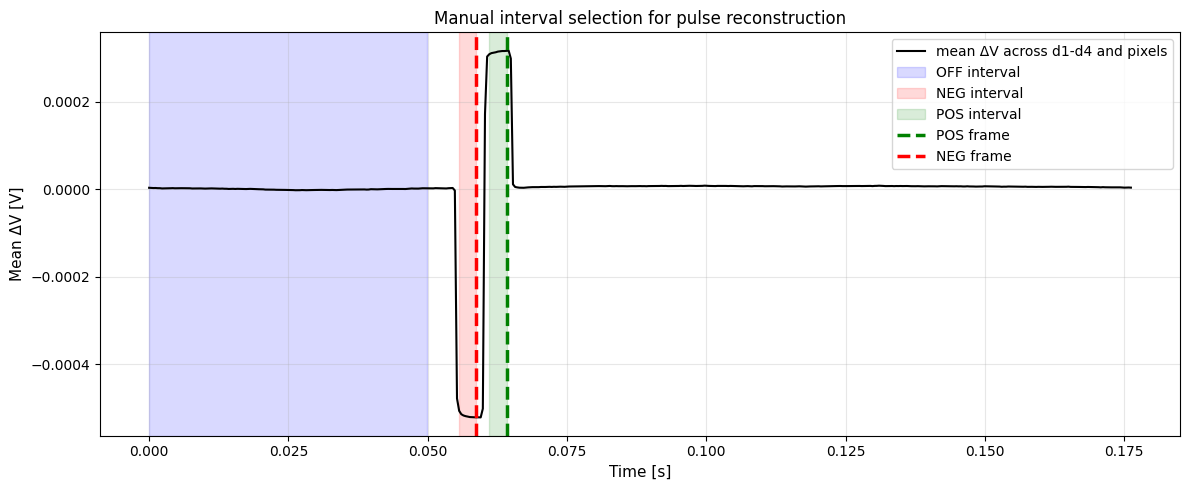


✓ Manual interval selection complete.


In [22]:
# ============================================================
# Manual interval selection
# ============================================================
# These intervals are chosen from the diagnostic mean pulse trace.
# They can be adjusted after visual inspection.
#
# Units:
#   seconds
# ============================================================

OFF_TIME = (0.0000, 0.0500)
NEG_TIME = (0.0553, 0.0589)
POS_TIME = (0.0609, 0.0645)

off_indices = np.where((time_s >= OFF_TIME[0]) & (time_s <= OFF_TIME[1]))[0]
neg_indices = np.where((time_s >= NEG_TIME[0]) & (time_s <= NEG_TIME[1]))[0]
pos_indices = np.where((time_s >= POS_TIME[0]) & (time_s <= POS_TIME[1]))[0]

if len(off_indices) < 3:
    raise ValueError("OFF interval has too few frames. Adjust OFF_TIME.")

if len(neg_indices) < 2:
    raise ValueError("NEG interval has too few frames. Adjust NEG_TIME.")

if len(pos_indices) < 2:
    raise ValueError("POS interval has too few frames. Adjust POS_TIME.")

print("Selected intervals:")
print(f"OFF: {OFF_TIME[0]:.6f} to {OFF_TIME[1]:.6f} s | frames {off_indices[0]} to {off_indices[-1]} | n = {len(off_indices)}")
print(f"NEG: {NEG_TIME[0]:.6f} to {NEG_TIME[1]:.6f} s | frames {neg_indices[0]} to {neg_indices[-1]} | n = {len(neg_indices)}")
print(f"POS: {POS_TIME[0]:.6f} to {POS_TIME[1]:.6f} s | frames {pos_indices[0]} to {pos_indices[-1]} | n = {len(pos_indices)}")

# ============================================================
# Compute OFF baseline and phase traces
# ============================================================

V_off = np.nanmean(voltage_stack[:, off_indices, :], axis=1)

# Phase voltage differences from OFF
dV_time = voltage_stack - V_off[:, None, :]
mean_dV_trace = np.nanmean(dV_time, axis=(0, 2))

# ============================================================
# Select POS and NEG frames
# ============================================================
# Strategy: pick the frame in each interval with the strongest response.
# For POS: pick the maximum (most positive) in mean_dV_trace.
# For NEG: pick the minimum (most negative) in mean_dV_trace.

pos_relative_idx = np.nanargmax(mean_dV_trace[pos_indices])
neg_relative_idx = np.nanargmin(mean_dV_trace[neg_indices])

pos_idx = pos_indices[pos_relative_idx]
neg_idx = neg_indices[neg_relative_idx]

print("\n" + "=" * 60)
print("Selected frames for phase analysis:")
print("=" * 60)
print(f"OFF: frames {off_indices[0]} to {off_indices[-1]} (mean)")
print(f"     time {time_s[off_indices[0]]:.6f} to {time_s[off_indices[-1]]:.6f} s")
print(f"     mean signal = {np.nanmean(voltage_stack[:, off_indices, :]):.6g} V")

print(f"\nPOS: frame {pos_idx}")
print(f"     time {time_s[pos_idx]:.6f} s")
print(f"     mean ΔV = {mean_dV_trace[pos_idx]:.6g} V")
print(f"     percentile in POS interval: {100*pos_relative_idx/len(pos_indices):.1f}%")

print(f"\nNEG: frame {neg_idx}")
print(f"     time {time_s[neg_idx]:.6f} s")
print(f"     mean ΔV = {mean_dV_trace[neg_idx]:.6g} V")
print(f"     percentile in NEG interval: {100*neg_relative_idx/len(neg_indices):.1f}%")

# ============================================================
# Visualization
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(time_s, mean_dV_trace, color="black", lw=1.5, label="mean ΔV across d1-d4 and pixels")

# Highlight intervals
plt.axvspan(time_s[off_indices[0]], time_s[off_indices[-1]], 
            color="blue", alpha=0.15, label="OFF interval")
plt.axvspan(time_s[neg_indices[0]], time_s[neg_indices[-1]], 
            color="red", alpha=0.15, label="NEG interval")
plt.axvspan(time_s[pos_indices[0]], time_s[pos_indices[-1]], 
            color="green", alpha=0.15, label="POS interval")

# Mark selected frames
plt.axvline(time_s[pos_idx], color="green", ls="--", lw=2.5, label="POS frame")
plt.axvline(time_s[neg_idx], color="red", ls="--", lw=2.5, label="NEG frame")

plt.xlabel("Time [s]", fontsize=11)
plt.ylabel("Mean ΔV [V]", fontsize=11)
plt.title("Manual interval selection for pulse reconstruction", fontsize=12)
plt.legend(loc="best", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Manual interval selection complete.")

In [23]:
# ============================================================
# Build 2D image grid from 1D pixel index
# ============================================================

grid = np.zeros((grid_size, grid_size), dtype=int)

for idx in range(n_pixels):
    col = idx // grid_size
    row = idx % grid_size

    if col % 2 == 0:
        grid[grid_size - 1 - row, grid_size - 1 - col] = idx
    else:
        grid[row, grid_size - 1 - col] = idx

print("grid shape:", grid.shape)
print("grid pixel range:", grid.min(), "to", grid.max())

grid shape: (31, 31)
grid pixel range: 0 to 960


,axis,phase,p50_abs_dV_V,p95_abs_dV_V,max_abs_dV_V
0,d1,pos-off,0.000643,0.003039,0.004242
1,d1,neg-off,0.000753,0.005356,0.006517
2,d2,pos-off,0.000253,0.000631,0.000783
3,d2,neg-off,0.000441,0.001452,0.001790
4,d3,pos-off,0.000213,0.000471,0.000583
5,d3,neg-off,0.000221,0.000516,0.000671
6,d4,pos-off,0.000064,0.000187,0.000232
7,d4,neg-off,0.000052,0.000199,0.000283


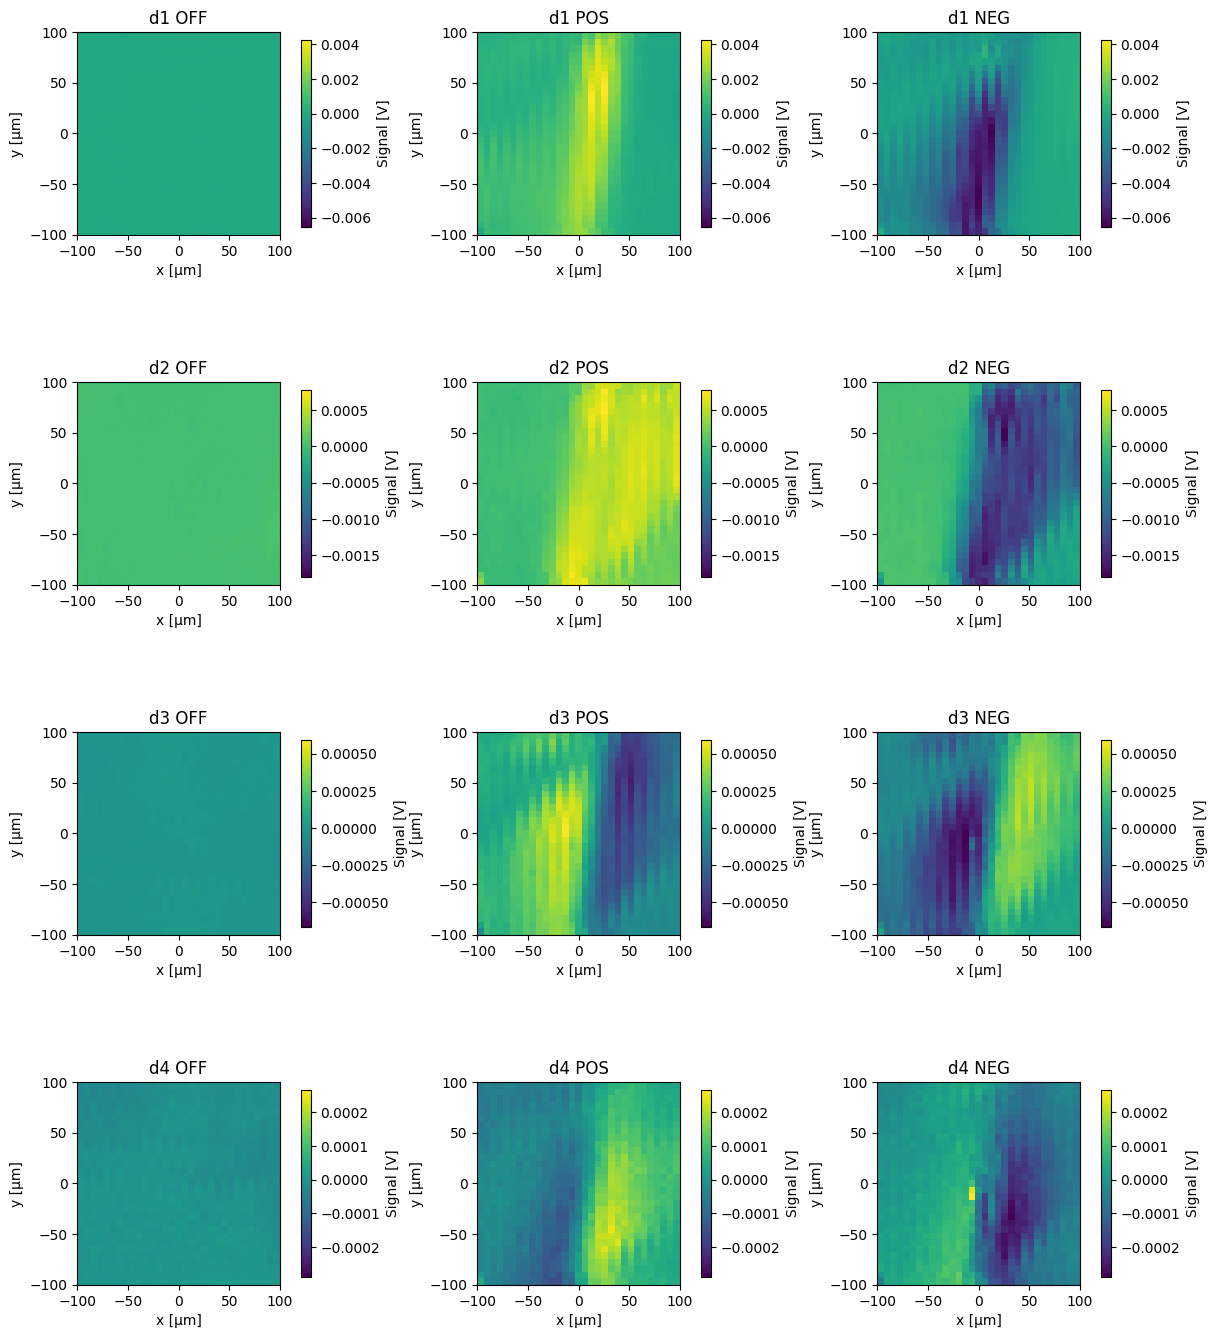

In [24]:
# ============================================================
# Compute OFF, POS, NEG voltage maps
# ============================================================

V_off = np.nanmean(voltage_stack[:, off_indices, :], axis=1)
V_pos = voltage_stack[:, pos_idx, :]
V_neg = voltage_stack[:, neg_idx, :]

dV_pos = V_pos - V_off
dV_neg = V_neg - V_off

dV_rows = []

for i, axis in enumerate(AXES_ORDER):
    for phase, arr in [("pos-off", dV_pos[i]), ("neg-off", dV_neg[i])]:
        dV_rows.append({
            "axis": axis,
            "phase": phase,
            "p50_abs_dV_V": np.nanpercentile(np.abs(arr), 50),
            "p95_abs_dV_V": np.nanpercentile(np.abs(arr), 95),
            "max_abs_dV_V": np.nanmax(np.abs(arr)),
        })

dV_summary_df = pd.DataFrame(dV_rows)
display(dV_summary_df)

# ============================================================
# Plot OFF/POS/NEG voltage maps
# ============================================================

Voff_maps = V_off[:, grid]
Vpos_maps = V_pos[:, grid]
Vneg_maps = V_neg[:, grid]

fig, axes = plt.subplots(4, 3, figsize=(12, 14), constrained_layout=True)

for i, axis in enumerate(AXES_ORDER):
    maps = [Voff_maps[i], Vpos_maps[i], Vneg_maps[i]]
    titles = [f"{axis} OFF", f"{axis} POS", f"{axis} NEG"]

    vmin = min(np.nanmin(m) for m in maps)
    vmax = max(np.nanmax(m) for m in maps)

    for j in range(3):
        im = axes[i, j].imshow(
            maps[j],
            extent=EXTENT_UM,
            origin="lower",
            aspect="equal",
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
        )
        axes[i, j].set_title(titles[j])
        axes[i, j].set_xlabel("x [µm]")
        axes[i, j].set_ylabel("y [µm]")

        cbar = plt.colorbar(im, ax=axes[i, j], fraction=0.046, pad=0.04)
        cbar.set_label("Signal [V]")

plt.show()

## Convert V to frequency

In [25]:
# ============================================================
# 2. Load calibration from A_results.csv
# ============================================================
# Required groups:
#   slope    : local ODMR slopes, units V/MHz
#   A_plus   : pseudoinverse matrix, units nT/MHz
# ============================================================

A_results_df = pd.read_csv(A_RESULTS_CSV_PATH)

available_groups = set(A_results_df["group"].unique())
required_groups = {"slope", "A_plus"}

missing_groups = required_groups - available_groups

if missing_groups:
    raise ValueError(
        f"A_results.csv is missing required groups: {missing_groups}. "
        "Rerun get_A_matrix.ipynb after adding the slope-saving cell."
    )

print("Available groups in A_results.csv:")
print(sorted(available_groups))

Available groups in A_results.csv:
['A', 'A_plus', 'A_plus_mT', 'B0', 'D', 'Mz', 'lower_center', 'metadata', 'pair_center', 'slope', 'slope_fit_quality', 'slope_intercept', 'slope_window', 'splitting', 'upper_center']


In [26]:
# ============================================================
# Extract slopes and A_plus
# ============================================================

slopes_V_per_MHz = np.zeros(4, dtype=float)

for i, axis in enumerate(AXES_ORDER):
    rows = A_results_df[
        (A_results_df["group"] == "slope") &
        (A_results_df["row"] == axis) &
        (A_results_df["col"] == "slope")
    ]

    if len(rows) == 0:
        raise ValueError(f"Missing slope for {axis}")

    unit = str(rows["unit"].iloc[0])
    if unit != "V/MHz":
        raise ValueError(f"Unexpected slope unit for {axis}: {unit}")

    slopes_V_per_MHz[i] = float(rows["value"].iloc[0])

Aplus_nT_per_MHz = np.zeros((3, 4), dtype=float)

for i, comp in enumerate(["Bx", "By", "Bz"]):
    for j, axis in enumerate(AXES_ORDER):
        rows = A_results_df[
            (A_results_df["group"] == "A_plus") &
            (A_results_df["row"] == comp) &
            (A_results_df["col"] == axis)
        ]

        if len(rows) == 0:
            raise ValueError(f"Missing A_plus entry for {comp}, {axis}")

        value = float(rows["value"].iloc[0])
        unit = str(rows["unit"].iloc[0])

        if unit == "nT/MHz":
            Aplus_nT_per_MHz[i, j] = value
        elif unit == "mT/MHz":
            Aplus_nT_per_MHz[i, j] = 1e6 * value
        else:
            raise ValueError(f"Unexpected A_plus unit for {comp}, {axis}: {unit}")

slopes_df = pd.DataFrame({
    "axis": AXES_ORDER,
    "slope_V_per_MHz": slopes_V_per_MHz,
})

Aplus_df = pd.DataFrame(
    Aplus_nT_per_MHz,
    index=["Bx", "By", "Bz"],
    columns=AXES_ORDER,
)

print("ODMR slopes loaded from A_results.csv:")
display(slopes_df)

print("A_plus loaded from A_results.csv [nT/MHz]:")
display(Aplus_df)

ODMR slopes loaded from A_results.csv:


,axis,slope_V_per_MHz
0,d1,-0.005998
1,d2,-0.006857
2,d3,-0.002656
3,d4,-0.001930


A_plus loaded from A_results.csv [nT/MHz]:


,d1,d2,d3,d4
Bx,-1968.013832,-2925.969304,-22872.279884,-22384.337275
By,-22954.201724,-22530.378498,-407.550787,-322.273020
Bz,-15620.222195,15784.051468,-13867.328226,14754.846591


In [27]:
# ============================================================
# Convert voltage changes to frequency shifts
# ============================================================
# Formula:
#   Δν [MHz] = ΔV [V] / slope [V/MHz]
# ============================================================

deltaNu_pos_MHz = dV_pos / slopes_V_per_MHz[:, None]
deltaNu_neg_MHz = dV_neg / slopes_V_per_MHz[:, None]

deltaNu_rows = []

for i, axis in enumerate(AXES_ORDER):
    for phase, arr in [("pos-off", deltaNu_pos_MHz[i]), ("neg-off", deltaNu_neg_MHz[i])]:
        deltaNu_rows.append({
            "axis": axis,
            "phase": phase,
            "p50_abs_deltaNu_MHz": np.nanpercentile(np.abs(arr), 50),
            "p95_abs_deltaNu_MHz": np.nanpercentile(np.abs(arr), 95),
            "max_abs_deltaNu_MHz": np.nanmax(np.abs(arr)),
        })

deltaNu_summary_df = pd.DataFrame(deltaNu_rows)
display(deltaNu_summary_df)

print("Sanity note:")
print("If Δν is comparable to or larger than the ODMR linewidth,")
print("then the local linear slope approximation is not valid.")

,axis,phase,p50_abs_deltaNu_MHz,p95_abs_deltaNu_MHz,max_abs_deltaNu_MHz
0,d1,pos-off,0.107261,0.506662,0.707219
1,d1,neg-off,0.125463,0.893004,1.086598
2,d2,pos-off,0.036951,0.092067,0.114129
3,d2,neg-off,0.064370,0.211719,0.260979
4,d3,pos-off,0.080269,0.177355,0.219389
5,d3,neg-off,0.083185,0.194197,0.252551
6,d4,pos-off,0.033261,0.096786,0.120350
7,d4,neg-off,0.027067,0.102957,0.146773


Sanity note:
If Δν is comparable to or larger than the ODMR linewidth,
then the local linear slope approximation is not valid.


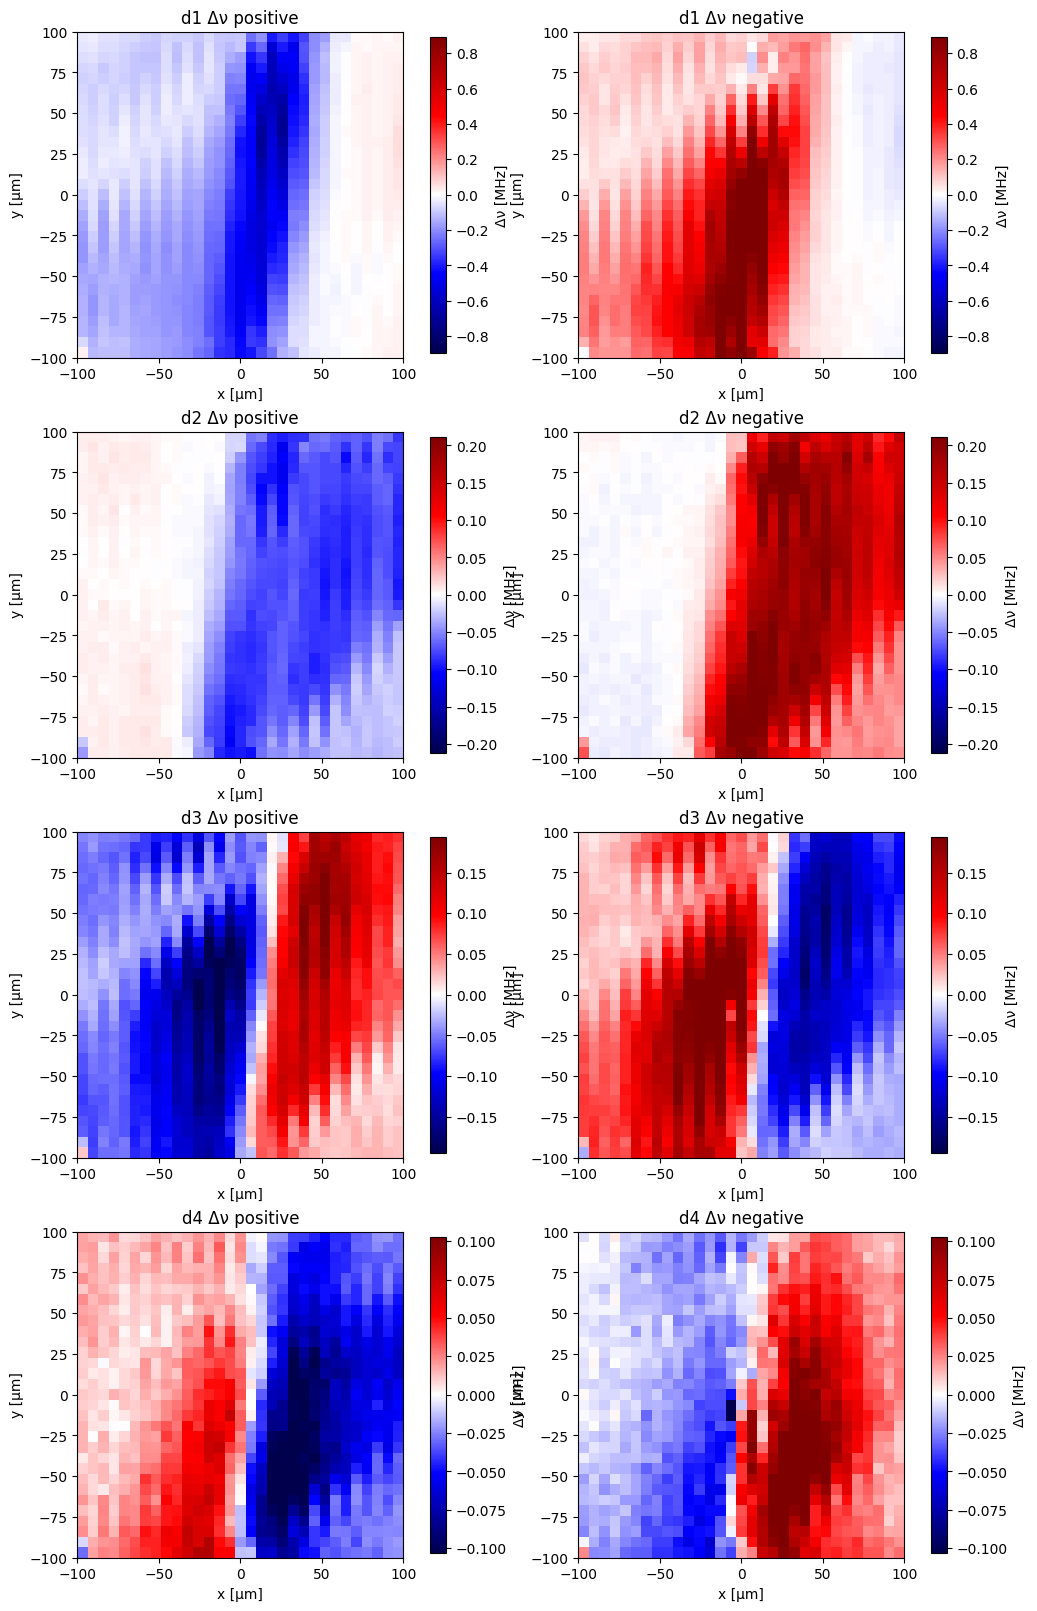

In [28]:
# ============================================================
# Plot frequency-shift maps
# ============================================================

deltaNu_pos_maps = deltaNu_pos_MHz[:, grid]
deltaNu_neg_maps = deltaNu_neg_MHz[:, grid]

fig, axes = plt.subplots(4, 2, figsize=(10, 16), constrained_layout=True)

for i, axis in enumerate(AXES_ORDER):
    lim = max(
        np.nanpercentile(np.abs(deltaNu_pos_maps[i]), 95),
        np.nanpercentile(np.abs(deltaNu_neg_maps[i]), 95),
    )

    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    im1 = axes[i, 0].imshow(
        deltaNu_pos_maps[i],
        extent=EXTENT_UM,
        origin="lower",
        aspect="equal",
        cmap="seismic",
        vmin=-lim,
        vmax=lim,
    )
    axes[i, 0].set_title(f"{axis} Δν positive")
    axes[i, 0].set_xlabel("x [µm]")
    axes[i, 0].set_ylabel("y [µm]")
    plt.colorbar(im1, ax=axes[i, 0], fraction=0.046, pad=0.04).set_label("Δν [MHz]")

    im2 = axes[i, 1].imshow(
        deltaNu_neg_maps[i],
        extent=EXTENT_UM,
        origin="lower",
        aspect="equal",
        cmap="seismic",
        vmin=-lim,
        vmax=lim,
    )
    axes[i, 1].set_title(f"{axis} Δν negative")
    axes[i, 1].set_xlabel("x [µm]")
    axes[i, 1].set_ylabel("y [µm]")
    plt.colorbar(im2, ax=axes[i, 1], fraction=0.046, pad=0.04).set_label("Δν [MHz]")

plt.show()

# ============================================================
# 3. Apply A_plus and reconstruct magnetic field
# ============================================================

In [29]:

# Formula:
#   B [nT] = A_plus [nT/MHz] @ Δν [MHz]
# ============================================================

B_pos_nT = Aplus_nT_per_MHz @ deltaNu_pos_MHz
B_neg_nT = Aplus_nT_per_MHz @ deltaNu_neg_MHz

B_rows = []

for i, comp in enumerate(["Bx", "By", "Bz"]):
    for phase, arr in [("pos-off", B_pos_nT[i]), ("neg-off", B_neg_nT[i])]:
        B_rows.append({
            "component": comp,
            "phase": phase,
            "p50_abs_B_nT": np.nanpercentile(np.abs(arr), 50),
            "p95_abs_B_nT": np.nanpercentile(np.abs(arr), 95),
            "max_abs_B_nT": np.nanmax(np.abs(arr)),
        })

B_summary_df = pd.DataFrame(B_rows)
display(B_summary_df)

,component,phase,p50_abs_B_nT,p95_abs_B_nT,max_abs_B_nT
0,Bx,pos-off,1246.918316,3329.457149,4476.706392
1,Bx,neg-off,1354.904745,5261.292389,7817.423261
2,By,pos-off,2804.953424,13545.186156,18496.664075
3,By,neg-off,4649.617908,24337.362705,29577.966976
4,Bz,pos-off,3362.695163,7384.981626,10412.514709
5,Bz,neg-off,4075.127265,13615.925309,16115.868663


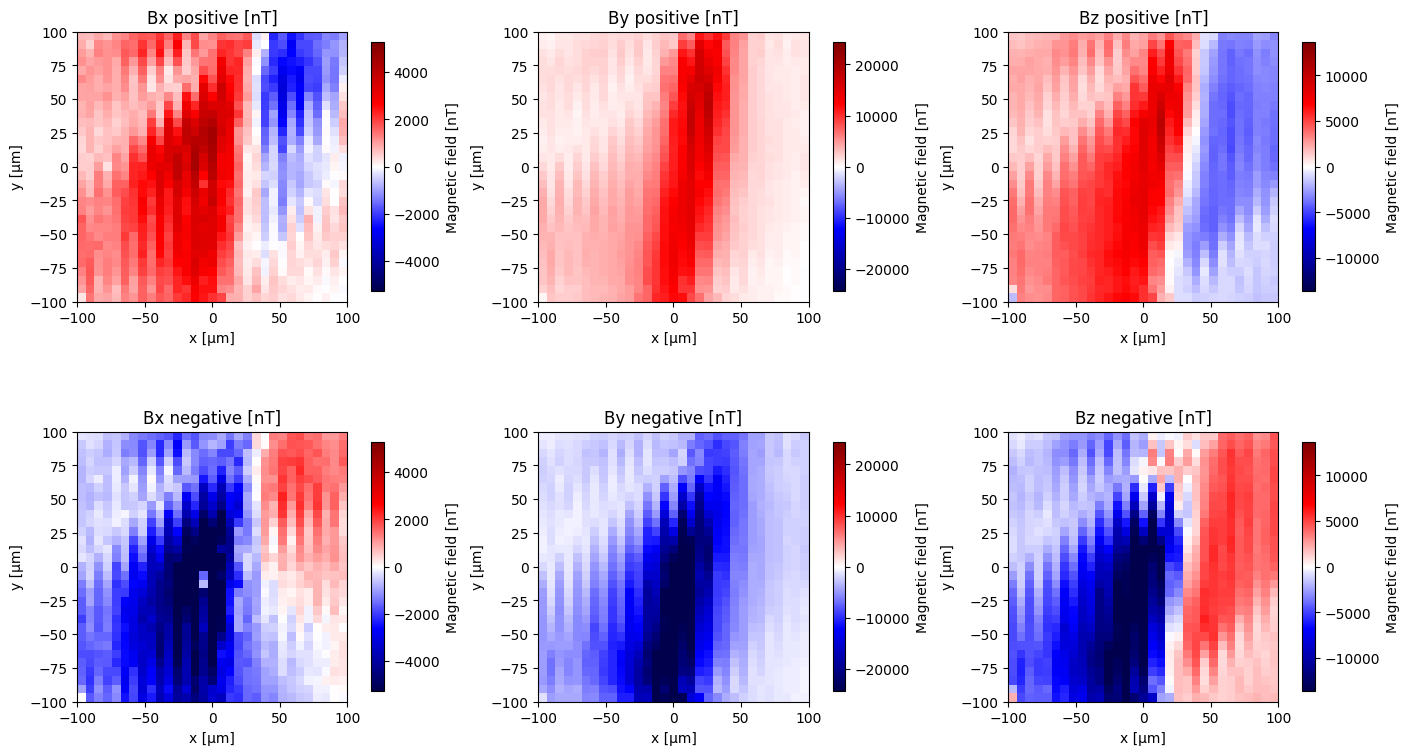

In [30]:
# ============================================================
# Plot reconstructed B-field maps
# ============================================================

Bx_pos_map = B_pos_nT[0][grid]
By_pos_map = B_pos_nT[1][grid]
Bz_pos_map = B_pos_nT[2][grid]

Bx_neg_map = B_neg_nT[0][grid]
By_neg_map = B_neg_nT[1][grid]
Bz_neg_map = B_neg_nT[2][grid]

Bx_lim = max(
    np.nanpercentile(np.abs(Bx_pos_map), 95),
    np.nanpercentile(np.abs(Bx_neg_map), 95),
)

By_lim = max(
    np.nanpercentile(np.abs(By_pos_map), 95),
    np.nanpercentile(np.abs(By_neg_map), 95),
)

Bz_lim = max(
    np.nanpercentile(np.abs(Bz_pos_map), 95),
    np.nanpercentile(np.abs(Bz_neg_map), 95),
)

maps = [
    ("Bx positive", Bx_pos_map, Bx_lim),
    ("By positive", By_pos_map, By_lim),
    ("Bz positive", Bz_pos_map, Bz_lim),
    ("Bx negative", Bx_neg_map, Bx_lim),
    ("By negative", By_neg_map, By_lim),
    ("Bz negative", Bz_neg_map, Bz_lim),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for ax, (title, data, lim) in zip(axes.ravel(), maps):
    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    im = ax.imshow(
        data,
        extent=EXTENT_UM,
        origin="lower",
        aspect="equal",
        cmap="seismic",
        vmin=-lim,
        vmax=lim,
    )

    ax.set_title(f"{title} [nT]")
    ax.set_xlabel("x [µm]")
    ax.set_ylabel("y [µm]")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Magnetic field [nT]")

plt.show()

EARLY UNIT-SCALE DIAGNOSTIC

Pulse data structure
--------------------
voltage_stack shape: (4, 457, 961)
Meaning: voltage_stack[channel, time, pixel]
channels: 4 ['d1', 'd2', 'd3', 'd4']
time range [s]: 0.0 to 0.1761984
dt [s]: 0.0003864000000000003
frame rate [Hz]: 2587.991718426499

Representative pulse values
---------------------------
These are the values exactly as saved in the .npy pulse files.
Unit label is not assumed here; call them raw pulse units for now.

d1:
  frame   0 | t = 0.000000 s | pixels [0, 100, 250, 450, 700, 900]: 1.86e-05, 7.19e-05, 1.08e-05, -8.18e-06, -1.81e-06, 1.03e-05
  frame 114 | t = 0.044050 s | pixels [0, 100, 250, 450, 700, 900]: -1.21e-06, 9.83e-07, -1.36e-06, -3.65e-05, 5.91e-06, 6.59e-06
  frame 228 | t = 0.088099 s | pixels [0, 100, 250, 450, 700, 900]: 1.13e-05, -1.37e-06, 1.13e-05, -1.45e-05, -2.55e-05, 2.33e-05
  frame 342 | t = 0.132149 s | pixels [0, 100, 250, 450, 700, 900]: 6.54e-05, 4.18e-05, 2.48e-05, 3.15e-06, -8.57e-06, 1.12e-05
  fra

,axis,global_p50_abs_deltaS_raw,global_p95_abs_deltaS_raw,global_max_abs_deltaS_raw,active_p50_abs_deltaS_raw,active_p95_abs_deltaS_raw,active_max_abs_deltaS_raw
0,d1,0.000013,0.000110,0.006537,0.000656,0.004347,0.006537
1,d2,0.000011,0.000072,0.001795,0.000314,0.001340,0.001795
2,d3,0.000008,0.000076,0.000672,0.000215,0.000492,0.000672
3,d4,0.000013,0.000069,0.000325,0.000057,0.000196,0.000325



ODMR slopes loaded from A_results.csv
-------------------------------------


,axis,slope,unit,abs_slope
0,d1,-0.005998,V/MHz,0.005998
1,d2,-0.006857,V/MHz,0.006857
2,d3,-0.002656,V/MHz,0.002656
3,d4,-0.001930,V/MHz,0.001930



Implied Δν if raw pulse units are treated as ODMR volts
-------------------------------------------------------


,axis,active_p50_abs_deltaS_raw,active_p95_abs_deltaS_raw,active_max_abs_deltaS_raw,abs_slope_V_per_MHz,implied_p50_deltaNu_MHz_if_raw_equals_V,implied_p95_deltaNu_MHz_if_raw_equals_V,implied_max_deltaNu_MHz_if_raw_equals_V
0,d1,0.000656,0.004347,0.006537,0.005998,0.109439,0.724807,1.089844
1,d2,0.000314,0.001340,0.001795,0.006857,0.045751,0.195478,0.261773
2,d3,0.000215,0.000492,0.000672,0.002656,0.080887,0.185222,0.253069
3,d4,0.000057,0.000196,0.000325,0.001930,0.029392,0.101405,0.168562



Scale factor needed for an example plausible p95 shift
------------------------------------------------------
Example target: active p95 |Δν| ≈ 0.1 MHz
This is NOT a calibration; it only quantifies the mismatch.


,axis,active_p95_abs_deltaS_raw,abs_slope_V_per_MHz,target_deltaNu_MHz,required_raw_to_ODMR_V_factor
0,d1,0.004347,0.005998,0.1,0.137968
1,d2,0.001340,0.006857,0.1,0.511567
2,d3,0.000492,0.002656,0.1,0.539894
3,d4,0.000196,0.001930,0.1,0.986140


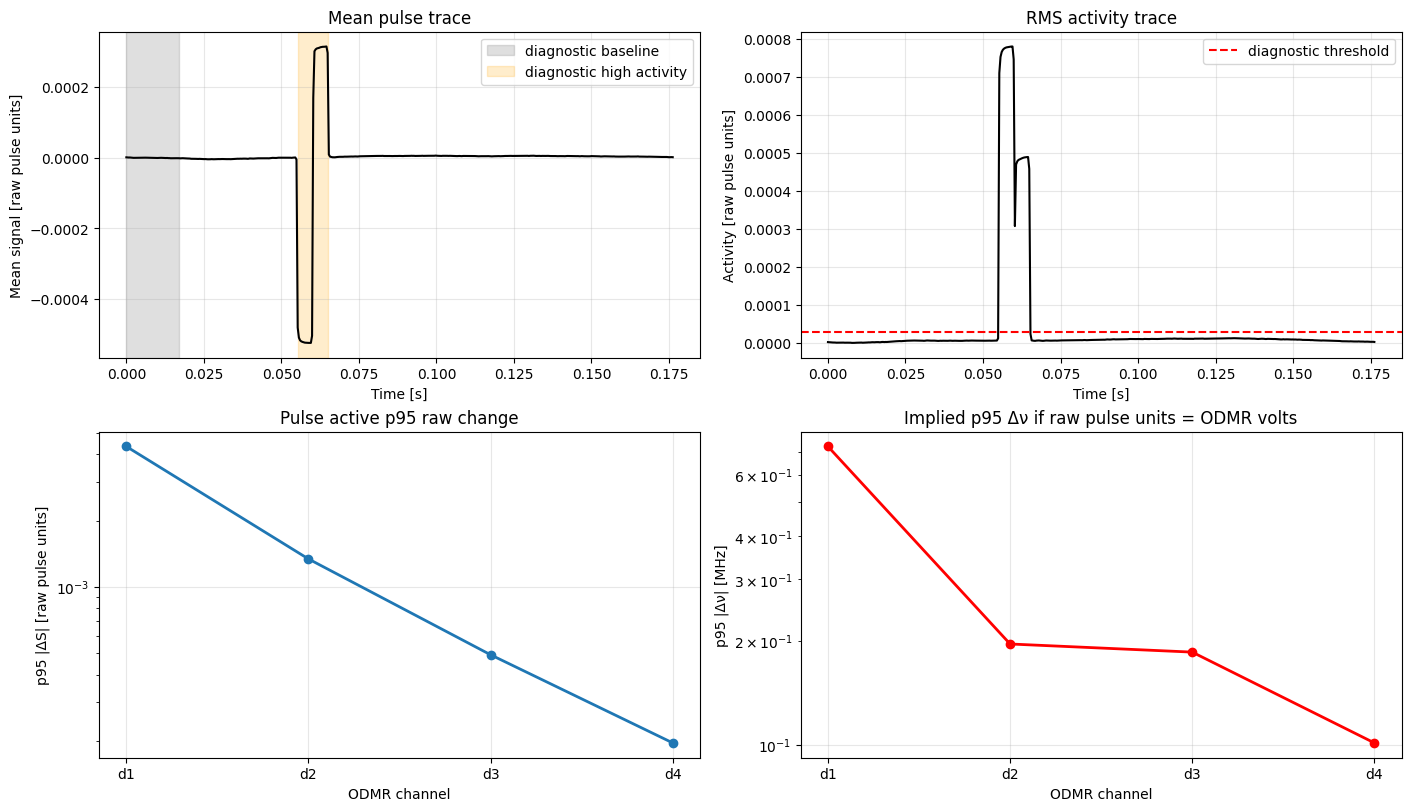


Conclusion
----------
This diagnostic did not use final OFF/POS/NEG intervals.
It only compared the raw pulse scale with the ODMR slopes saved in A_results.csv.

If the implied Δν values are enormous, the pulse raw units cannot be treated
as the same volts used for the ODMR slope calibration.

Before calibrated B-field reconstruction, you need one of:
  1. a measured raw-pulse-unit → ODMR-voltage conversion factor, or
  2. ODMR slopes measured directly in the same raw pulse units.


In [31]:
# ============================================================
# Early diagnostic: pulse raw scale vs ODMR calibration scale
# ============================================================
# Use this BEFORE final OFF/POS/NEG intervals are chosen.
#
# It estimates baseline from an early quiet part of the trace and
# reports how large the pulse signal is compared with the ODMR slopes.
# This is diagnostic only; it does not define final reconstruction intervals.
# ============================================================

print("=" * 80)
print("EARLY UNIT-SCALE DIAGNOSTIC")
print("=" * 80)

# ------------------------------------------------------------
# 1. Basic pulse structure
# ------------------------------------------------------------

print("\nPulse data structure")
print("--------------------")
print("voltage_stack shape:", voltage_stack.shape)
print("Meaning: voltage_stack[channel, time, pixel]")
print("channels:", len(AXES_ORDER), AXES_ORDER)
print("time range [s]:", time_s[0], "to", time_s[-1])
print("dt [s]:", np.median(np.diff(time_s)))
print("frame rate [Hz]:", 1 / np.median(np.diff(time_s)))

# ------------------------------------------------------------
# 2. Print representative raw pulse values
# ------------------------------------------------------------

sample_pixels = [0, 100, 250, 450, 700, 900]
sample_pixels = [p for p in sample_pixels if p < voltage_stack.shape[2]]

sample_time_indices = [
    0,
    int(0.25 * len(time_s)),
    int(0.50 * len(time_s)),
    int(0.75 * len(time_s)),
    len(time_s) - 1,
]

print("\nRepresentative pulse values")
print("---------------------------")
print("These are the values exactly as saved in the .npy pulse files.")
print("Unit label is not assumed here; call them raw pulse units for now.")

for axis_i, axis in enumerate(AXES_ORDER):
    print(f"\n{axis}:")
    for t_idx in sample_time_indices:
        vals = voltage_stack[axis_i, t_idx, sample_pixels]
        vals_str = ", ".join([f"{v:.3g}" for v in vals])
        print(
            f"  frame {t_idx:3d} | t = {time_s[t_idx]:.6f} s "
            f"| pixels {sample_pixels}: {vals_str}"
        )

# ------------------------------------------------------------
# 3. Build a mean trace and estimate a provisional baseline
# ------------------------------------------------------------

channel_mean = np.nanmean(voltage_stack, axis=2)       # [channel, time]
mean_all_channels = np.nanmean(channel_mean, axis=0)   # [time]

# Provisional baseline: first 10% of frames.
# This is NOT the final OFF interval; it is only for scale diagnostics.
baseline_end = max(5, int(0.10 * len(time_s)))
baseline_indices_diag = np.arange(0, baseline_end)

baseline_per_channel = np.nanmedian(channel_mean[:, baseline_indices_diag], axis=1)
centered_channel_mean = channel_mean - baseline_per_channel[:, None]

activity = np.sqrt(np.nanmean(centered_channel_mean**2, axis=0))

# Provisional high-activity frame candidates.
activity_threshold = (
    np.nanmedian(activity)
    + 5.0 * 1.4826 * (np.nanmedian(np.abs(activity - np.nanmedian(activity))) + 1e-15)
)

high_activity_indices = np.where(activity > activity_threshold)[0]

print("\nProvisional baseline used only for diagnostics")
print("----------------------------------------------")
print(f"baseline frames: 0 to {baseline_end - 1}")
print(f"baseline time: {time_s[0]:.6f} to {time_s[baseline_end - 1]:.6f} s")

if len(high_activity_indices) > 0:
    print("\nDetected high-activity region, diagnostic only:")
    print(f"first high-activity frame: {high_activity_indices[0]}, t = {time_s[high_activity_indices[0]]:.6f} s")
    print(f"last high-activity frame:  {high_activity_indices[-1]}, t = {time_s[high_activity_indices[-1]]:.6f} s")
else:
    print("\nNo high-activity region detected with this diagnostic threshold.")

# ------------------------------------------------------------
# 4. Diagnostic pulse difference scale
# ------------------------------------------------------------
# Compare every frame to the provisional baseline and summarize the largest changes.
# This avoids needing final OFF/POS/NEG intervals.
# ------------------------------------------------------------

baseline_maps_diag = np.nanmedian(voltage_stack[:, baseline_indices_diag, :], axis=1)
dS_time_diag = voltage_stack - baseline_maps_diag[:, None, :]

pulse_scale_rows = []

for i, axis in enumerate(AXES_ORDER):
    all_abs = np.abs(dS_time_diag[i]).ravel()

    # Also summarize only high-activity frames if available.
    if len(high_activity_indices) > 0:
        active_abs = np.abs(dS_time_diag[i, high_activity_indices, :]).ravel()
    else:
        active_abs = all_abs

    pulse_scale_rows.append({
        "axis": axis,
        "global_p50_abs_deltaS_raw": np.nanpercentile(all_abs, 50),
        "global_p95_abs_deltaS_raw": np.nanpercentile(all_abs, 95),
        "global_max_abs_deltaS_raw": np.nanmax(all_abs),
        "active_p50_abs_deltaS_raw": np.nanpercentile(active_abs, 50),
        "active_p95_abs_deltaS_raw": np.nanpercentile(active_abs, 95),
        "active_max_abs_deltaS_raw": np.nanmax(active_abs),
    })

pulse_scale_diag_df = pd.DataFrame(pulse_scale_rows)

print("\nPulse raw-change scale using provisional baseline")
print("-------------------------------------------------")
display(pulse_scale_diag_df)

# ------------------------------------------------------------
# 5. Load ODMR slopes from A_results.csv
# ------------------------------------------------------------

slope_rows = []

for axis in AXES_ORDER:
    rows = A_results_df[
        (A_results_df["group"] == "slope") &
        (A_results_df["row"] == axis) &
        (A_results_df["col"] == "slope")
    ]

    if len(rows) == 0:
        raise ValueError(f"Missing ODMR slope for {axis} in A_results.csv")

    slope_value = float(rows["value"].iloc[0])
    slope_unit = str(rows["unit"].iloc[0])

    slope_rows.append({
        "axis": axis,
        "slope": slope_value,
        "unit": slope_unit,
        "abs_slope": abs(slope_value),
    })

slope_scale_df = pd.DataFrame(slope_rows)

print("\nODMR slopes loaded from A_results.csv")
print("-------------------------------------")
display(slope_scale_df)

# ------------------------------------------------------------
# 6. Show implied frequency shifts if raw pulse units are treated as ODMR volts
# ------------------------------------------------------------

implied_rows = []

for i, axis in enumerate(AXES_ORDER):
    abs_slope = slope_scale_df.loc[slope_scale_df["axis"] == axis, "abs_slope"].iloc[0]

    active_p50 = pulse_scale_diag_df.loc[
        pulse_scale_diag_df["axis"] == axis,
        "active_p50_abs_deltaS_raw"
    ].iloc[0]

    active_p95 = pulse_scale_diag_df.loc[
        pulse_scale_diag_df["axis"] == axis,
        "active_p95_abs_deltaS_raw"
    ].iloc[0]

    active_max = pulse_scale_diag_df.loc[
        pulse_scale_diag_df["axis"] == axis,
        "active_max_abs_deltaS_raw"
    ].iloc[0]

    implied_rows.append({
        "axis": axis,
        "active_p50_abs_deltaS_raw": active_p50,
        "active_p95_abs_deltaS_raw": active_p95,
        "active_max_abs_deltaS_raw": active_max,
        "abs_slope_V_per_MHz": abs_slope,
        "implied_p50_deltaNu_MHz_if_raw_equals_V": active_p50 / abs_slope,
        "implied_p95_deltaNu_MHz_if_raw_equals_V": active_p95 / abs_slope,
        "implied_max_deltaNu_MHz_if_raw_equals_V": active_max / abs_slope,
    })

implied_deltaNu_df = pd.DataFrame(implied_rows)

print("\nImplied Δν if raw pulse units are treated as ODMR volts")
print("-------------------------------------------------------")
display(implied_deltaNu_df)

# ------------------------------------------------------------
# 7. Estimate the scale factor required for plausible Δν
# ------------------------------------------------------------

target_deltaNu_MHz = 0.1

factor_rows = []

for i, axis in enumerate(AXES_ORDER):
    abs_slope = slope_scale_df.loc[slope_scale_df["axis"] == axis, "abs_slope"].iloc[0]

    active_p95 = pulse_scale_diag_df.loc[
        pulse_scale_diag_df["axis"] == axis,
        "active_p95_abs_deltaS_raw"
    ].iloc[0]

    required_factor = target_deltaNu_MHz * abs_slope / active_p95

    factor_rows.append({
        "axis": axis,
        "active_p95_abs_deltaS_raw": active_p95,
        "abs_slope_V_per_MHz": abs_slope,
        "target_deltaNu_MHz": target_deltaNu_MHz,
        "required_raw_to_ODMR_V_factor": required_factor,
    })

required_scale_df = pd.DataFrame(factor_rows)

print("\nScale factor needed for an example plausible p95 shift")
print("------------------------------------------------------")
print(f"Example target: active p95 |Δν| ≈ {target_deltaNu_MHz} MHz")
print("This is NOT a calibration; it only quantifies the mismatch.")
display(required_scale_df)

# ------------------------------------------------------------
# 8. Plots
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

# Mean traces
axes[0, 0].plot(time_s, mean_all_channels, color="black", lw=1.5)
axes[0, 0].axvspan(
    time_s[baseline_indices_diag[0]],
    time_s[baseline_indices_diag[-1]],
    color="gray",
    alpha=0.25,
    label="diagnostic baseline"
)
if len(high_activity_indices) > 0:
    axes[0, 0].axvspan(
        time_s[high_activity_indices[0]],
        time_s[high_activity_indices[-1]],
        color="orange",
        alpha=0.2,
        label="diagnostic high activity"
    )
axes[0, 0].set_title("Mean pulse trace")
axes[0, 0].set_xlabel("Time [s]")
axes[0, 0].set_ylabel("Mean signal [raw pulse units]")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Activity trace
axes[0, 1].plot(time_s, activity, color="black", lw=1.5)
axes[0, 1].axhline(activity_threshold, color="red", ls="--", label="diagnostic threshold")
axes[0, 1].set_title("RMS activity trace")
axes[0, 1].set_xlabel("Time [s]")
axes[0, 1].set_ylabel("Activity [raw pulse units]")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Pulse scale
axes[1, 0].plot(
    pulse_scale_diag_df["axis"],
    pulse_scale_diag_df["active_p95_abs_deltaS_raw"],
    marker="o",
    lw=2
)
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Pulse active p95 raw change")
axes[1, 0].set_xlabel("ODMR channel")
axes[1, 0].set_ylabel("p95 |ΔS| [raw pulse units]")
axes[1, 0].grid(True, alpha=0.3)

# Implied frequency shifts
axes[1, 1].plot(
    implied_deltaNu_df["axis"],
    implied_deltaNu_df["implied_p95_deltaNu_MHz_if_raw_equals_V"],
    marker="o",
    lw=2,
    color="red"
)
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Implied p95 Δν if raw pulse units = ODMR volts")
axes[1, 1].set_xlabel("ODMR channel")
axes[1, 1].set_ylabel("p95 |Δν| [MHz]")
axes[1, 1].grid(True, alpha=0.3)

plt.show()

# ------------------------------------------------------------
# 9. Final conclusion
# ------------------------------------------------------------

print("\nConclusion")
print("----------")
print("This diagnostic did not use final OFF/POS/NEG intervals.")
print("It only compared the raw pulse scale with the ODMR slopes saved in A_results.csv.")
print()
print("If the implied Δν values are enormous, the pulse raw units cannot be treated")
print("as the same volts used for the ODMR slope calibration.")
print()
print("Before calibrated B-field reconstruction, you need one of:")
print("  1. a measured raw-pulse-unit → ODMR-voltage conversion factor, or")
print("  2. ODMR slopes measured directly in the same raw pulse units.")